# <b>Preprocess Data</b>
The cleaned matrix is subjected to normalization of UMI counts per cell, followed by the selection of Highly Variable Genes (HVGs).

---

## 1. Setup Environment

### 1.1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scanpy as sc

### 1.2. Define File Paths/Directories

In [2]:
import config

# Cleaned AnnData file
CLEANED_ANNDATA_FILE = config.PROCESSED_DATA_DIR / "Norman_2019_cleaned.h5ad"
print("Cleaned AnnData file:\n", CLEANED_ANNDATA_FILE)

# Preprocessed AnnData file save directory
PREPROCESSED_ANNDATA_FILE = config.PROCESSED_DATA_DIR / "Norman_2019_preprocessed.h5ad"
print("\nPreprocessed AnnData file will be saved to:\n", PREPROCESSED_ANNDATA_FILE)

# Figures save directory
FIGURES_DIR = config.FIGURES_DIR
print("\nFigures will be saved to:\n", FIGURES_DIR)

Cleaned AnnData file:
 ..\01_data\02_processed\Norman_2019_cleaned.h5ad

Preprocessed AnnData file will be saved to:
 ..\01_data\02_processed\Norman_2019_preprocessed.h5ad

Figures will be saved to:
 ..\03_figures


### 1.3. Define Global Parameters

In [3]:
SEED = config.SEED

np.random.seed(SEED)
sc.settings.seed = SEED

print(f"\nRandom seed set to: {SEED}")


Random seed set to: 42


---

## 2. Load And Validate Data

### 2.1. Load Cleaned AnnData

In [4]:
# Read the raw AnnData file
print("\nReading cleaned AnnData file...")
adata = sc.read_h5ad(CLEANED_ANNDATA_FILE)
print(adata)


Reading cleaned AnnData file...
AnnData object with n_obs × n_vars = 100047 × 19996
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804',

### 2.2. Inspect Data

In [5]:
print("Cell IDs:\n", adata.obs_names)
print("\nGene IDs:\n", adata.var_names)

print("\nGene symbols:\n", adata.var.gene_symbols)

print("\nSample data matrix (first 5 rows and columns):\n", adata.X[:5, :5].toarray())

Cell IDs:
 Index(['AAACCTGAGGCATGTG-1', 'AAACCTGAGGCCCTTG-1', 'AAACCTGCACGAAGCA-1',
       'AAACCTGCAGCCTTGG-1', 'AAACCTGCATCTCCCA-1', 'AAACCTGCATTACCTT-1',
       'AAACCTGGTATAATGG-1', 'AAACCTGGTATCGCAT-1', 'AAACCTGGTATGAAAC-1',
       'AAACCTGGTCCATCCT-1',
       ...
       'TTTGTCAGTATAAACG-8', 'TTTGTCAGTCACTTCC-8', 'TTTGTCAGTCAGAATA-8',
       'TTTGTCAGTCATGCAT-8', 'TTTGTCAGTCCATGAT-8', 'TTTGTCATCACTCCTG-8',
       'TTTGTCATCAGTACGT-8', 'TTTGTCATCCACTCCA-8', 'TTTGTCATCCCAACGG-8',
       'TTTGTCATCTGGCGAC-8'],
      dtype='object', name='index', length=100047)

Gene IDs:
 Index(['RP11-34P13.3', 'RP11-34P13.7', 'FO538757.3', 'FO538757.2',
       'AP006222.2', 'RP4-669L17.10', 'RP5-857K21.4', 'RP11-206L10.9',
       'LINC00115', 'FAM41C',
       ...
       'AC136616.1', 'BX004987.4', 'AC145212.4', 'AC145212.2', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.1', 'AC240274.1'],
      dtype='object', length=19996)

Gene symbols:
 RP11-34P13.3    RP11-34P13.3
RP1

### 2.3. Validate Data

#### 2.3.1. Verify Raw UMI Counts
Check if the data entirely consists of whole numbers, therefore proving that it contains raw UMI counts.

In [6]:
is_raw_counts = np.all(adata.X.data == np.floor(adata.X.data))

if is_raw_counts:
    print("\nData matrix contains raw UMI counts.")
else:
    print("\nFAILED: Data matrix does NOT contain raw UMI counts.")


Data matrix contains raw UMI counts.


#### 2.3.2. Index Genes By Symbol
Index genes by their symbols instead of Ensembl IDs.

In [7]:
# Check if genes are already indexed by their symbols
are_genes_ens_ids = adata.var_names.str.startswith("ENSG").all()

# Map to gene symbols if currently indexed by Ensembl IDs
if are_genes_ens_ids:
    print("\nGenes are indexed by Ensembl IDs. Mapping to gene symbols....")

    # Check if gene symbols are unique
    if adata.var.gene_symbols.is_unique:
        print("Gene symbols are unique. Setting gene symbols as index....")
        adata.var_names = adata.var['gene_symbols'].values
        print("\nGene symbols set as index successfully.")
    else:
        print("\nGene symbols are NOT unique.")

        # How many duplicates?
        duplicates = adata.var['gene_symbols'][adata.var['gene_symbols'].duplicated(keep=False)]
        print(f"Number of duplicate gene symbol entries: {len(duplicates)}")
        print(duplicates.value_counts().head())

        # Make gene symbols unique by appending a suffix to duplicates
        print("\nMaking gene symbols unique and setting them as index....")
        adata.var_names = adata.var['gene_symbols'].values
        adata.var_names_make_unique()
        print("Gene symbols made unique and set as index successfully.")

# If genes are already indexed by gene symbols, no mapping is needed
else:
    print("\nGenes are already indexed by gene symbols. No mapping needed.")

print("\nGene IDs:\n", adata.var_names)


Genes are already indexed by gene symbols. No mapping needed.

Gene IDs:
 Index(['RP11-34P13.3', 'RP11-34P13.7', 'FO538757.3', 'FO538757.2',
       'AP006222.2', 'RP4-669L17.10', 'RP5-857K21.4', 'RP11-206L10.9',
       'LINC00115', 'FAM41C',
       ...
       'AC136616.1', 'BX004987.4', 'AC145212.4', 'AC145212.2', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.1', 'AC240274.1'],
      dtype='object', length=19996)


#### 2.3.4. Verify Uniqueness Of Cell IDs

In [8]:
are_cell_ids_unique = adata.obs_names.is_unique

if are_cell_ids_unique:
    print("\nCell IDs are unique.")
else:
    print("\nFAILED: Cell IDs are NOT unique.")


Cell IDs are unique.


---

## 3. Normalize Data

### 3.1. Stash Raw UMI Counts Before Normalization

In [9]:
print("Stashing raw counts in adata.layers['counts']...")
adata.layers['counts'] = adata.X.copy()
print("\nadata.layers['counts'] set to a copy of the raw counts matrix. Inspecting values in adata.layers['counts']:")
print(adata.layers['counts'][:5, :5].toarray())

Stashing raw counts in adata.layers['counts']...

adata.layers['counts'] set to a copy of the raw counts matrix. Inspecting values in adata.layers['counts']:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0.]]


### 3.2. Perform CP10K Normalization
Normalize UMI counts of all genes in all cells such that the total UMI count of all genes in each cell is `10,000`.

In [10]:
# Normalize each cell to 10,000 counts
print("\nNormalizing each cell to 10,000 counts (CP10K normalization)...")
sc.pp.normalize_total(adata, target_sum=1e4)
print("CP10K normalization complete.")

# Inspect total counts per cell
cell_sums = np.array(adata.X.sum(axis=1)).flatten()
print(f"Cell total counts after normalization (should all be ~10000):")
print(
    f"Min: {cell_sums.min():.1f}, Max: {cell_sums.max():.1f}, Mean: {cell_sums.mean():.1f}"
)

print("\nInspecting first 5 rows and columns of normalized data matrix (should now have floats):\n", adata.X[:5, :5].toarray())


Normalizing each cell to 10,000 counts (CP10K normalization)...
CP10K normalization complete.
Cell total counts after normalization (should all be ~10000):
Min: 10000.0, Max: 10000.0, Mean: 10000.0

Inspecting first 5 rows and columns of normalized data matrix (should now have floats):
 [[0.        0.        0.        0.        0.       ]
 [0.        0.        0.        0.4305149 0.       ]
 [0.        0.        0.        0.        0.       ]
 [0.        0.        0.        0.        1.0599396]
 [0.        0.        0.        0.        0.       ]]


### 3.3. Apply Log1P Transformation To CP10K Normalized Data

In [13]:
# Apply log1p transformation to the normalized data
print("\nApplying log1p transformation to normalized data...")
sc.pp.log1p(adata)
print("log1p transformation complete.")

# Inspect the data matrix after log1p transformation
sample_values = adata.X[:5, :5].toarray()
print(
    "Inspecting first 5 rows and columns after log1p (should have lesser float values now):"
)
print(sample_values)


Applying log1p transformation to normalized data...
log1p transformation complete.
Inspecting first 5 rows and columns after log1p (should have lesser float values now):
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.35803443 0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.7226767 ]
 [0.         0.         0.         0.         0.        ]]


## 4. Select Highly Variable Genes (HVGs)


Identifying the top 3000 highly variable genes using the 'seurat_v3' method...
Highly variable gene identification complete.


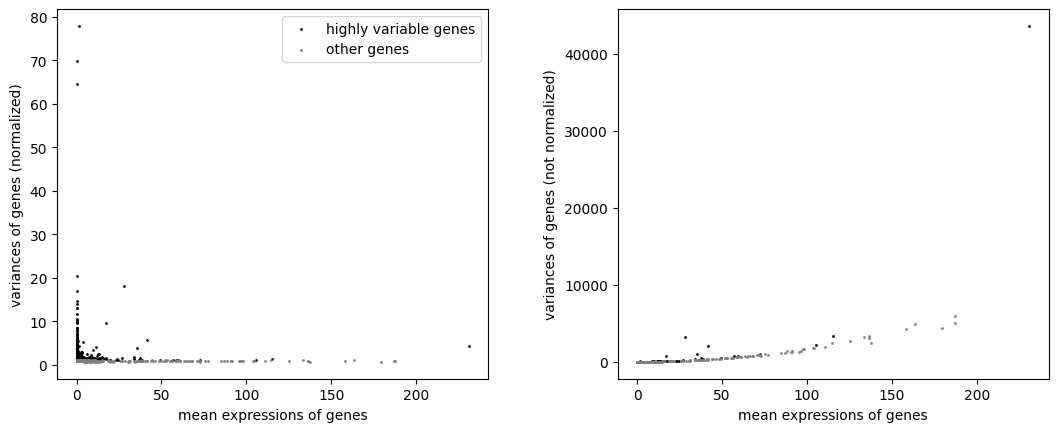

Total HVGs selected: 3000


In [20]:
# Select the top N HVGs
top_n_hvgs = 3000  # Iteratively adjusted

# Identify highly variable genes
print(
    f"\nIdentifying the top {top_n_hvgs} highly variable genes using the 'seurat_v3' method..."
)
sc.pp.highly_variable_genes(
    adata, flavor="seurat_v3", n_top_genes=top_n_hvgs, layer="counts"
)
print("Highly variable gene identification complete.")

# Plot and save
fig = sc.pl.highly_variable_genes(adata, show=False)
plt.savefig(str(config.FIGURES_DIR / "03_hvgs.png"), bbox_inches="tight")
plt.show()

print(f"Total HVGs selected: {adata.var['highly_variable'].sum()}")

---

## 5. Perform Final Sanity Checks

In [23]:
print("=== POST-PREPROCESSING SANITY CHECK ===\n")

# Verify normalization
x_max = adata.X.data.max()
x_min = adata.X.data.min()
assert x_min >= 0, "Negative values found — normalization error"
assert (
    x_max <= np.log1p(1e4) + 0.01
), f"Max value {x_max:.3f} exceeds log1p(10000) — log1p may not have been applied"
print(f"Normalization and log1p verified (value range: {x_min:.3f} - {x_max:.3f})")

# Verify raw counts layer preserved
assert "counts" in adata.layers, "Raw counts layer missing"
assert np.all(
    adata.layers["counts"].data == np.floor(adata.layers["counts"].data)
), "Raw counts layer contains non-integers"
print("Raw counts layer preserved")

# Verify HVGs selected
assert adata.var["highly_variable"].sum() == 3000, "HVG count mismatch"
print("HVGs selected: 3000")

print("\nAll assertions passed.")

=== POST-PREPROCESSING SANITY CHECK ===

Normalization and log1p verified (value range: 0.323 - 8.399)
Raw counts layer preserved
HVGs selected: 3000

All assertions passed.


---

## 6. Save Cleaned AnnData

In [24]:
adata.write_h5ad(PREPROCESSED_ANNDATA_FILE)
print(f"Saved: {PREPROCESSED_ANNDATA_FILE}")

Saved: ..\01_data\02_processed\Norman_2019_preprocessed.h5ad


---

## 7. Summary

### 7.1. Data Validation
- Gene symbols confirmed as index (no Ensembl IDs)
- Cell barcodes confirmed unique
- Raw UMI counts confirmed as integers

### 7.2. Steps Executed
- Raw counts stashed in `adata.layers['counts']` before normalization
- CP10K normalization — each cell scaled to 10,000 total counts
- log1p transformation — compresses dynamic range, handles zeros
- HVG selection — top 3,000 highly variable genes identified using seurat_v3 method

### 7.3. Parameters
- Normalization target: 10,000 counts per cell
- HVG method: seurat_v3 (variance-based, uses raw counts layer)
- Number of HVGs: 3,000